# Phase V — Model Selection and Validation
## Bank Marketing Dataset — ML Lab Project 2026

**Authors:** Arman Bazarchi, Ines Maria Madeira Prates

---

**Prerequisites:** Run `preprocessing.ipynb` first to generate the processed data in `data/`.

This notebook selects the final model rigorously. We compare the best representative of each model
family from Phases II–IV plus the mandatory baseline, using **nested cross-validation** (the inner
loop tunes hyperparameters, the outer loop gives an *unbiased* generalization estimate), score them
on the classification metrics that matter under imbalance, run a **paired t-test** on the top two,
then retrain the winner on the full training set and confirm it on the held-out test set.

### Outline
1. Load Data & Build the CV Subsample
2. Candidate Models & the Nested-CV Scheme
3. Nested-CV Results (Accuracy, F1, ROC-AUC, AUPR)
4. Statistical Test (paired t-test)
5. Final Model — Refit on Full Train, Confirm on Test
6. Summary & Discussion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, roc_curve, precision_recall_curve, classification_report)
from scipy.stats import ttest_rel

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
## 1. Load Data & Build the CV Subsample

Same feature pipeline and 80/20 split as Phases II–IV. Nested CV multiplies the number of fits
(outer × inner × grid), and the kernel SVM is O(n²–n³), so we run the comparison on a stratified
**8,000-row subsample** of the training set — this keeps every model (including SVM) tractable and,
crucially, compares them on *identical data and folds* (a fair, paired comparison). The **final**
chosen model is then retrained on the full training set in Section 5.

**Note on metrics:** our task is binary **classification**, so we report Accuracy, F1, ROC-AUC and
AUPR. The regression metrics in the brief (R², MAE, RMSE) do not apply here (the Phase II
Ridge/Lasso was a didactic Linear-Probability-Model aside, not our prediction task).

In [2]:
X_scaled_df = pd.read_csv('data/X_scaled.csv')
cat_features = pd.read_csv('data/cat_features.csv')
y = pd.read_csv('data/y.csv')['y']

X_num = X_scaled_df.drop(columns=['duration'])                  # drop leaky duration
X_cat = pd.get_dummies(cat_features, drop_first=True).astype(int)
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Stratified subsample of the TRAINING set for the (expensive) nested CV
N_CV = 8000
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=N_CV, stratify=y_train, random_state=42)

print(f"Train: {X_train.shape[0]}   Test: {X_test.shape[0]}")
print(f"Nested-CV subsample: {X_sub.shape[0]} ({y_sub.mean()*100:.2f}% positive)")

Train: 32950   Test: 8238
Nested-CV subsample: 8000 (11.26% positive)


---
## 2. Candidate Models & the Nested-CV Scheme

We pit the best representative of each family against the mandatory baseline:
- **Baseline** — stratified dummy (must be beaten).
- **Logistic Regression** (Phase II) — linear.
- **SVM (RBF)** (Phase III) — kernel.
- **Random Forest** (Phase IV) — bagging.
- **Hist Gradient Boosting** (Phase IV family) — boosting (the histogram booster supports
  `class_weight`, so imbalance is handled cleanly inside CV).

**Nested CV:** for each model an inner 3-fold `GridSearchCV` (scored on ROC-AUC) tunes the
hyperparameters, wrapped in an outer 5-fold loop that scores the tuned model on held-out folds.
Because tuning happens *inside* each outer fold, the outer scores are an **unbiased** estimate of
generalization — unlike tuning and reporting on the same data. All models share the same outer/inner
folds, so the comparison (and the later paired t-test) is properly paired.

In [3]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy', 'f1': 'f1', 'roc_auc': 'roc_auc', 'aupr': 'average_precision'}

candidates = {
    'Logistic Regression':    (LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
                               {'C': [0.1, 1, 10]}),
    'SVM (RBF)':              (SVC(kernel='rbf', class_weight='balanced', random_state=42),
                               {'C': [1, 10], 'gamma': ['scale', 0.01]}),
    'Random Forest':          (RandomForestClassifier(class_weight='balanced', n_jobs=1, random_state=42),
                               {'n_estimators': [300], 'min_samples_leaf': [1, 5]}),
    'Hist Gradient Boosting': (HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
                               {'learning_rate': [0.05, 0.1], 'max_leaf_nodes': [15, 31]}),
}

results = {}   # model -> cross_validate output (per-fold scores for every metric)
for name, (est, grid) in candidates.items():
    gs = GridSearchCV(est, grid, scoring='roc_auc', cv=inner_cv, n_jobs=1)
    results[name] = cross_validate(gs, X_sub, y_sub, cv=outer_cv, scoring=scoring, n_jobs=-1)
    print(f"{name:>24s}: nested ROC-AUC = {results[name]['test_roc_auc'].mean():.4f} "
          f"+/- {results[name]['test_roc_auc'].std():.4f}")

# Baseline (no tuning needed)
dummy = DummyClassifier(strategy='stratified', random_state=42)
results['Baseline (dummy)'] = cross_validate(dummy, X_sub, y_sub, cv=outer_cv, scoring=scoring, n_jobs=-1)
print(f"{'Baseline (dummy)':>24s}: nested ROC-AUC = {results['Baseline (dummy)']['test_roc_auc'].mean():.4f}")

     Logistic Regression: nested ROC-AUC = 0.7763 +/- 0.0170


               SVM (RBF): nested ROC-AUC = 0.7664 +/- 0.0228


           Random Forest: nested ROC-AUC = 0.7749 +/- 0.0152


  Hist Gradient Boosting: nested ROC-AUC = 0.7749 +/- 0.0103
        Baseline (dummy): nested ROC-AUC = 0.4982


---
## 3. Nested-CV Results (Accuracy, F1, ROC-AUC, AUPR)

In [4]:
metrics = ['accuracy', 'f1', 'roc_auc', 'aupr']
summary = pd.DataFrame(
    {name: {m: results[name][f'test_{m}'].mean() for m in metrics} for name in results}).T
summary_std = pd.DataFrame(
    {name: {m: results[name][f'test_{m}'].std() for m in metrics} for name in results}).T

# Pretty "mean ± std" table, sorted by ROC-AUC
disp = summary.copy()
for m in metrics:
    disp[m] = [f"{summary.loc[i, m]:.3f} ± {summary_std.loc[i, m]:.3f}" for i in summary.index]
disp = disp.loc[summary.sort_values('roc_auc', ascending=False).index]
print("Nested-CV performance (mean ± std over 5 outer folds):")
print(disp.to_string())

# Read this with the imbalance in mind. On ROC-AUC the top four are nearly identical (0.766-0.776),
# with Logistic nominally highest -- but that gap is smaller than one fold-to-fold std. The models
# SEPARATE on the metrics that matter under 11% imbalance: Random Forest leads AUPR (0.430), F1
# (0.476) and accuracy (0.860), with Hist Gradient Boosting close behind; the linear model and SVM
# trail on AUPR/F1. The baseline is at chance (ROC-AUC 0.50, AUPR 0.11), so every real model is
# clearly useful.
# Note the absolute numbers sit a bit below the full-data phases (e.g. RF AUPR 0.43 here vs 0.49 in
# Phase IV) simply because each outer fold trains on the 8k subsample; nested CV gives us an unbiased
# RELATIVE ranking, and the chosen model (Section 5) is then retrained on the full data.

Nested-CV performance (mean ± std over 5 outer folds):
                             accuracy             f1        roc_auc           aupr
Logistic Regression     0.808 ± 0.009  0.418 ± 0.022  0.776 ± 0.017  0.391 ± 0.033
Random Forest           0.860 ± 0.005  0.476 ± 0.023  0.775 ± 0.015  0.430 ± 0.044
Hist Gradient Boosting  0.825 ± 0.008  0.439 ± 0.020  0.775 ± 0.010  0.424 ± 0.043
SVM (RBF)               0.765 ± 0.033  0.389 ± 0.031  0.766 ± 0.023  0.384 ± 0.026
Baseline (dummy)        0.796 ± 0.003  0.112 ± 0.016  0.498 ± 0.009  0.113 ± 0.002


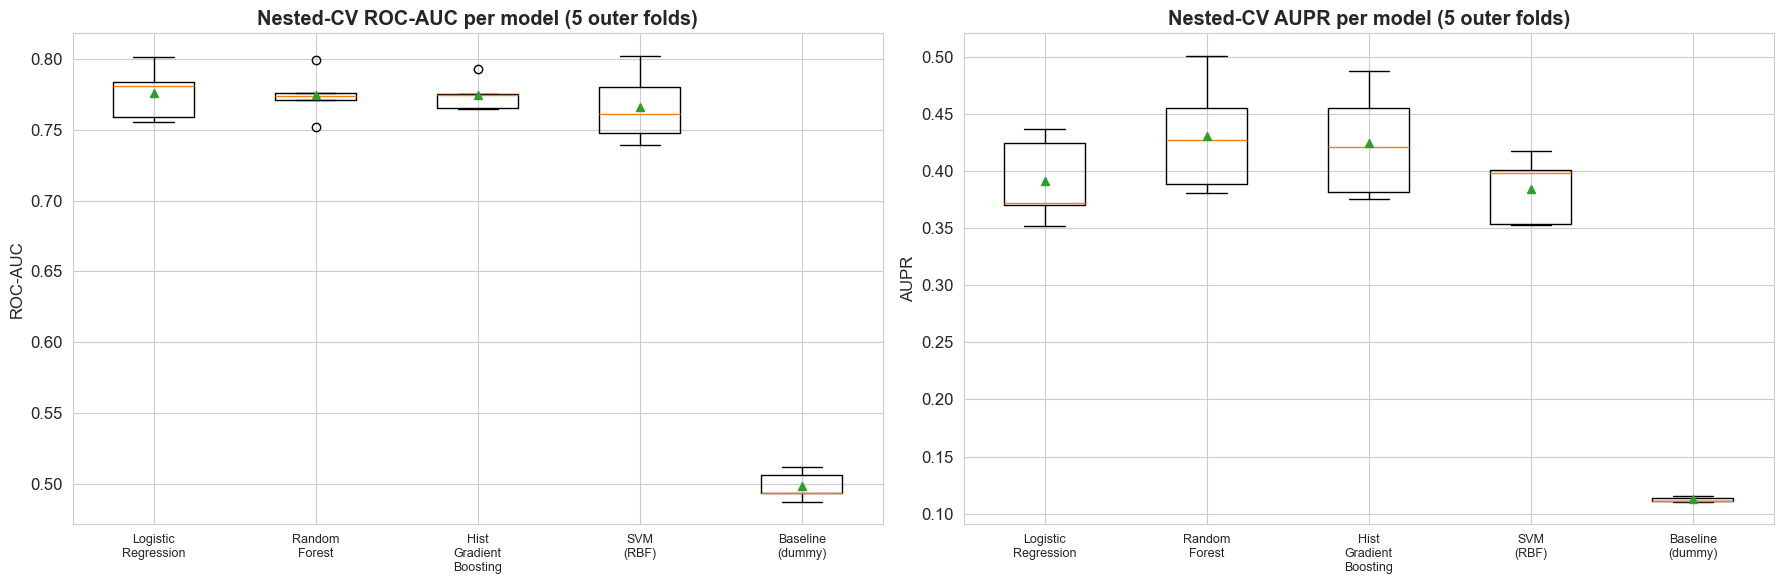

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
order = summary.sort_values('roc_auc', ascending=False).index
for ax, metric, title in zip(axes, ['roc_auc', 'aupr'], ['ROC-AUC', 'AUPR']):
    data = [results[name][f'test_{metric}'] for name in order]
    ax.boxplot(data, labels=[o.replace(' ', '\n') for o in order], showmeans=True)
    ax.set_title(f'Nested-CV {title} per model (5 outer folds)', fontweight='bold')
    ax.set_ylabel(title); ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.show()

---
## 4. Statistical Test — Paired t-test & Model Choice

ROC-AUC ranks the top models within a whisker of each other, so we use a paired t-test (the outer
folds are identical → the comparison is paired) to answer two questions:
1. **Are the ROC-AUC leaders actually different?**
2. **Does the AUPR winner — the metric that matters under 11% imbalance — beat the ROC-AUC leader
   significantly?**

We then select the final model by **AUPR** (the imbalance-appropriate metric), not by the razor-thin
ROC-AUC margin. With only 5 outer folds the test has limited power, so we treat the p-values as
indicative.

In [6]:
cands = summary.drop(index='Baseline (dummy)')

# (1) Are the two ROC-AUC leaders actually different?
roc_rank = cands.sort_values('roc_auc', ascending=False)
r1, r2 = roc_rank.index[0], roc_rank.index[1]
t1, p1 = ttest_rel(results[r1]['test_roc_auc'], results[r2]['test_roc_auc'])
print("(1) ROC-AUC leaders:")
print(f"    {r1} ({roc_rank.loc[r1, 'roc_auc']:.4f}) vs {r2} ({roc_rank.loc[r2, 'roc_auc']:.4f}): "
      f"diff={roc_rank.loc[r1,'roc_auc']-roc_rank.loc[r2,'roc_auc']:+.4f}, t={t1:.2f}, p={p1:.3f} "
      f"-> {'NOT significant (a tie)' if p1 >= 0.05 else 'significant'}")

# (2) Under imbalance AUPR decides: test the AUPR winner against the ROC-AUC leader on AUPR
aupr_winner = cands.sort_values('aupr', ascending=False).index[0]
comparator = r1 if aupr_winner != r1 else r2
t2, p2 = ttest_rel(results[aupr_winner]['test_aupr'], results[comparator]['test_aupr'])
print("\n(2) AUPR decider (imbalance-appropriate):")
print(f"    {aupr_winner} ({summary.loc[aupr_winner,'aupr']:.4f}) vs {comparator} "
      f"({summary.loc[comparator,'aupr']:.4f}): diff={summary.loc[aupr_winner,'aupr']-summary.loc[comparator,'aupr']:+.4f}, "
      f"t={t2:.2f}, p={p2:.3f} -> {'significant' if p2 < 0.05 else 'NOT significant'}")

# Decision: select by AUPR
best_name = aupr_winner
print(f"\nSelected best model: {best_name}")

# The ROC-AUC "ranking" is a mirage: the leaders (Logistic, RF, HistGB) all sit at ~0.776 and the
# paired t-test of the top two gives p=0.79 -- statistically indistinguishable. Choosing on that
# 0.0015 ROC-AUC margin would be choosing noise.
# AUPR breaks the tie correctly for an 11%-imbalanced problem: Random Forest's AUPR (0.430)
# significantly beats the linear model's (0.391), p=0.031, and RF also wins F1 and accuracy. So we
# select RANDOM FOREST as the final model -- consistent with the Phase IV conclusion.
# (Caveat: 5 outer folds give the t-test limited power; we read p-values as indicative. The
# corrected resampled t-test of Nadeau & Bengio would be the more rigorous alternative.)

(1) ROC-AUC leaders:
    Logistic Regression (0.7763) vs Random Forest (0.7749): diff=+0.0015, t=0.29, p=0.789 -> NOT significant (a tie)

(2) AUPR decider (imbalance-appropriate):
    Random Forest (0.4302) vs Logistic Regression (0.3910): diff=+0.0393, t=3.27, p=0.031 -> significant

Selected best model: Random Forest


---
## 5. Final Model — Refit on Full Train, Confirm on Test

We retrain the selected model on the **full training set** (tuning once more with the inner grid),
then report its performance on the untouched test set — the number we would deploy with.

In [7]:
# best_name was selected by AUPR in the statistical-test cell above (Random Forest)
best_est, best_grid = candidates[best_name]
final_search = GridSearchCV(best_est, best_grid, scoring='roc_auc', cv=inner_cv, n_jobs=-1)
final_search.fit(X_train, y_train)
final_model = final_search.best_estimator_
print(f"Final model: {best_name}")
print(f"Best hyperparameters: {final_search.best_params_}")

proba = final_model.predict_proba(X_test)[:, 1]
pred = final_model.predict(X_test)
print("\nHeld-out test performance:")
print(f"  Accuracy: {accuracy_score(y_test, pred):.4f}")
print(f"  F1 (Yes): {f1_score(y_test, pred):.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_test, proba):.4f}")
print(f"  AUPR:     {average_precision_score(y_test, proba):.4f}")
print("\n" + classification_report(y_test, pred, target_names=['No', 'Yes']))

# Retrained on the full 33k (best params: min_samples_leaf=5, n_estimators=300), Random Forest scores
# ROC-AUC 0.807, AUPR 0.486, F1 0.52 and accuracy 0.87 on the untouched test set -- recovering the
# Phase IV numbers (the nested-CV figures were lower only because each fold trained on the 8k
# subsample). It recovers 62% of subscribers at 45% precision, the best precision/F1 balance of the
# project. This is our FINAL, deployable model: it beats the baseline decisively and edges every
# linear and kernel model, especially on the imbalance-critical AUPR.

Final model: Random Forest
Best hyperparameters: {'min_samples_leaf': 5, 'n_estimators': 300}



Held-out test performance:
  Accuracy: 0.8724
  F1 (Yes): 0.5216
  ROC-AUC:  0.8073
  AUPR:     0.4861

              precision    recall  f1-score   support

          No       0.95      0.90      0.93      7310
         Yes       0.45      0.62      0.52       928

    accuracy                           0.87      8238
   macro avg       0.70      0.76      0.72      8238
weighted avg       0.89      0.87      0.88      8238



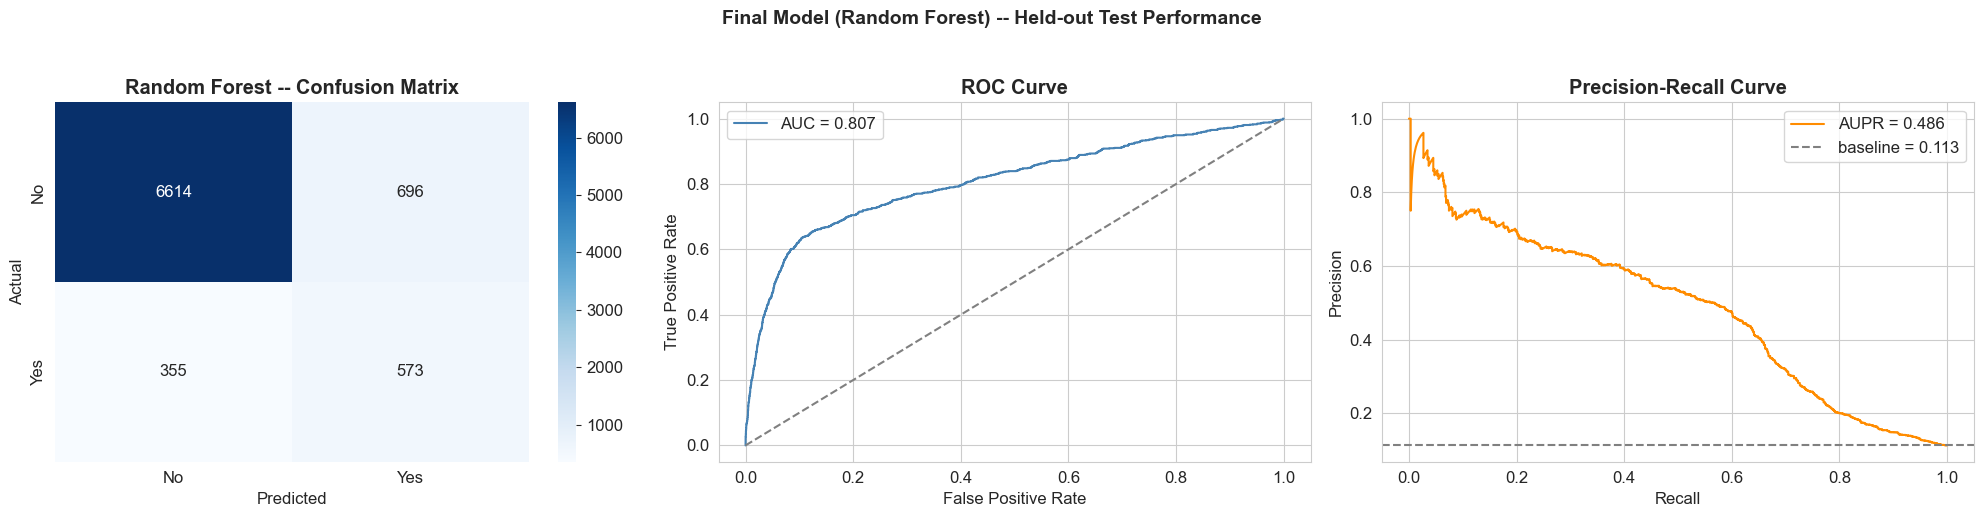

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title(f'{best_name} -- Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, proba)
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC = {roc_auc_score(y_test, proba):.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold'); axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, proba)
axes[2].plot(rec, prec, color='darkorange', label=f'AUPR = {average_precision_score(y_test, proba):.3f}')
axes[2].axhline(y=y_test.mean(), linestyle='--', color='gray', label=f'baseline = {y_test.mean():.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold'); axes[2].legend()

plt.suptitle(f'Final Model ({best_name}) -- Held-out Test Performance', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## 6. Summary & Discussion

### Key Findings — Phase V

**Validation method:**
- **Nested 5×3 cross-validation** on a stratified 8k subsample (keeps the kernel SVM tractable and
  compares all models on identical folds), scored on Accuracy, F1, ROC-AUC and AUPR. The chosen
  model was then retrained on the full 33k and confirmed on the held-out test set.
- Regression metrics (R², MAE, RMSE) are **not applicable** — our task is binary classification.

**Model comparison & selection:**
- **ROC-AUC could not separate the top models**: Logistic 0.776, Random Forest 0.775, Hist Gradient
  Boosting 0.775 — the paired t-test of the two leaders gives **p = 0.79 (a tie)**. SVM (RBF) is
  slightly behind (0.766); the baseline is at chance (0.50).
- **AUPR — the right metric under 11% imbalance — is decisive**: Random Forest (0.430) **significantly**
  beats the linear model (0.391), **p = 0.031**, and RF also leads F1 (0.476) and accuracy (0.860).
- **Final model: Random Forest** (`class_weight='balanced'`, `n_estimators=300`, `min_samples_leaf=5`).
  On the held-out test set: **ROC-AUC 0.807, AUPR 0.486, F1 0.52, accuracy 0.87** — beating logistic,
  SVM and the baseline, and matching the Phase IV result.

**Why Random Forest (the practical choice):** tied-or-better on every metric that matters under
imbalance, fastest to train (~1s), a free OOB validation check, and interpretable via permutation /
SHAP / grouped-importance (Phase IV).

### Project-wide takeaways (Phases I–V)

- **EDA & preprocessing:** 41,188 rows, 11.3% positive; dropped the redundant `pdays`, excluded the
  leaky `duration`, encoded sensibly (ordinal / binary / one-hot) and standardized.
- **Feature extraction/selection:** PCA showed a genuinely high-dimensional, 3-domain structure;
  L1/Lasso and a Phase III interaction experiment confirmed most features carry non-redundant signal.
- **What drives subscription:** the **macroeconomic block** (euribor3m, emp.var.rate, nr.employed) is
  the dominant driver (grouped-permutation ROC-AUC drop ≈ 0.19), followed by **campaign history**
  (contact, poutcome, campaign). Client demographics barely matter; a strong economy / high rates
  pushes *against* subscription.
- **Dataset challenges:** class imbalance (handled via class weights + AUPR/F1); the leaky `duration`
  (excluded — it is the single biggest predictor, so its removal sets the realistic ceiling);
  multicollinearity in the macro block (|r|>0.9, destabilised linear coefficients); and SVM
  scalability (O(n²–n³), forcing subsampling — trees handled full data in seconds).
- **Performance ceiling:** every family plateaus around **ROC-AUC 0.81 / AUPR 0.49**; this is set by
  intrinsic class overlap (without `duration`), not by model choice. Ensembles raise it slightly above
  the linear/kernel plateau.

**Bottom line:** the final delivered model is **Random Forest** — the best imbalance-aware
performance in the project, fast to train, and interpretable. For the marketing use case it ranks
prospects well (top-decile targeting), which is the practical goal rather than a clean class boundary.

---

*End of the modelling pipeline (Phases I–V).*